<a href="https://colab.research.google.com/github/victoriairungu99-creator/CDAV-course/blob/main/Pandas_cleaning_activity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
df=pd.read_csv("/content/health_clinic (1).csv")

In [ ]:
#DATA INSPECTION
df.head()

,patient id,Name,Age,Gender,County,Visit Date,Diagnosis,Temp,BP,Fee
0,P00801,Grace Wanjiku,35.0,F,Nairobi,17/04/2025,Diabetes,37.3,NaN,1500
1,P00583,Isaac Korir,23.0,f,Nakuru,16/02/2025,Pneumonia,36.1,157/72,1500
2,P00450,Ruth Wanjiku,17.0,F,Nyeri,11 Jul 2025,Diabetes,37.7,NaN,1200
3,P01664,Diana Wafula,59.0,male,Meru,2025-11-08,Typhoid,40.1,NaN,500
4,P02829,Felix Barasa,56.0,male,Nairobi,08/09/2025,Malaria,39.1,113/94,500


In [ ]:
df.shape

(3045, 10)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3045 entries, 0 to 3044
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   patient id  3045 non-null   object 
 1   Name        3045 non-null   object 
 2   Age         2882 non-null   float64
 3   Gender      2282 non-null   object 
 4   County      3045 non-null   object 
 5   Visit Date  3045 non-null   object 
 6   Diagnosis   2849 non-null   object 
 7   Temp        2594 non-null   object 
 8   BP          2657 non-null   object 
 9   Fee         2956 non-null   object 
dtypes: float64(1), object(9)
memory usage: 238.0+ KB


In [ ]:
df.describe() #gives you a statistical summary of any column that is already numerical (in this case,age)

,Age
count,2882.000000
mean,55.782096
std,102.960163
min,-3.000000
25%,22.000000
50%,44.500000
75%,68.000000
max,999.000000


In [ ]:
df.dtypes #get to see the data type of each column

,0
patient_id,object
name,object
age,int64
gender,object
county,object
visit_date,datetime64[ns]
diagnosis,object
temp,object
bp,object
fee,float64


In [ ]:
#DATA CLEANING
df.columns #how names of columns llok before cleaning

Index(['patient id', 'Name', 'Age', 'Gender', 'County', 'Visit Date',
       'Diagnosis', 'Temp', 'BP', 'Fee'],
      dtype='object')

In [ ]:
df.columns = df.columns.str.replace(" ","_").str.lower() #str. is a function that enables the instruction along with it to be applied on every column
df.columns #new display of columnms after cleaning

Index(['patient_id', 'name', 'age', 'gender', 'county', 'visit_date',
       'diagnosis', 'temp', 'bp', 'fee'],
      dtype='object')

In [ ]:
df.isna().sum()

,0
patient_id,0
name,0
age,163
gender,763
county,0
visit_date,0
diagnosis,196
temp,451
bp,388
fee,89


In [ ]:
df.duplicated().sum()#find no. of dupliucate rows

np.int64(45)

In [ ]:
print('rows:', len(df))
print('distinct txn_id:', df["patient_id"].nunique())

rows: 3045
distinct txn_id: 3000


In [ ]:
cleaned_fee=(df['fee'].astype(str)
                     .str.replace(',', '', regex=False)
)
df['fee'] = pd.to_numeric(cleaned_fee, errors='coerce')
df['fee'].dtype        # now a real number

dtype('float64')

In [ ]:
df["fee"].isna().sum()

np.int64(131)

In [ ]:
df["fee"].describe()

,fee
count,2914.000000
mean,708.861016
std,508.397676
min,-497.000000
25%,300.000000
50%,500.000000
75%,1200.000000
max,1500.000000


In [ ]:
print('negative amounts:', (df['fee'] < 0).sum())
df.loc[df['fee'] < 0, 'fee'] = np.nan

negative amounts: 132


In [ ]:
df["fee"].head(15)

,fee
0,1500.0
1,1500.0
2,1200.0
3,500.0
4,500.0
5,1500.0
6,1500.0
7,500.0
8,1200.0
9,1200.0


In [ ]:
df['county'] = (df['county'].str.strip() #to make the countries one, in one formart
                            .str.title()
)

df['county'].value_counts()

,count
county,
Nakuru,221
Eldoret,220
Machakos,219
Mombasa,216
Kitale,211
Nyeri,210
Kericho,204
Kisumu,201
Bungoma,201


In [ ]:
# Check data type
print(df["age"].dtype)

float64


In [ ]:
# Check missing values
print(df["age"].isna().sum())


163


In [ ]:
# Replace impossible ages with NaN
df.loc[(df["age"] < 0) | (df["age"] > 120), "age"] = np.nan

In [ ]:
# Fill missing values with the median
df["age"] = df["age"].fillna(df["age"].median())


In [ ]:
# Convert float to integer
df["age"] = df["age"].astype(int)

In [ ]:
df["age"].dtype
df["age"].head(10)

,age
0,35
1,23
2,17
3,59
4,56
5,31
6,50
7,54
8,21
9,2


In [177]:
df["age"].describe()

,age
count,3045.000000
mean,44.560591
std,24.806267
min,0.000000
25%,25.000000
50%,44.000000
75%,65.000000
max,90.000000


In [ ]:
df["gender"].isna().sum()

np.int64(763)

In [ ]:
df["gender"].dtype

dtype('O')

In [ ]:
df["gender"].unique()

array(['F', 'f', 'male', 'Female', nan, 'M', 'Male'], dtype=object)

In [ ]:
df["gender"] = (
    df["gender"]
    .str.strip()
    .str.lower()
    .replace({
        "male": "M",
        "m": "M",
        "female": "F",
        "f": "F"
    })
)
df["gender"].unique()

array(['F', 'M', nan], dtype=object)

In [ ]:
df['diagnosis'] = (df['diagnosis'].str.title()
)
df["diagnosis"].head(15)

,diagnosis
0,Diabetes
1,Pneumonia
2,Diabetes
3,Typhoid
4,Malaria
5,Malaria
6,Injury
7,Hypertension
8,Diarrhea
9,Typhoid


In [ ]:
#Right  now the data type for visit dates is object ,we convert it to dates
df['visit_date'] = pd.to_datetime(df['visit_date'], dayfirst=True, errors='coerce')
df['visit_date'].dtype        # now a real date

dtype('<M8[ns]')

In [ ]:
# for temp
# Check data type
df["temp"].dtype


dtype('O')

In [ ]:
# Convert the column to numeric
df["temp"] = pd.to_numeric(df["temp"], errors="coerce")

# Check the data type again
df["temp"].dtype


dtype('float64')

In [ ]:
# Check for missing values
df["temp"].isna().sum()


np.int64(681)

In [ ]:
# Replace unrealistic temperatures with NaN
df.loc[(df["temp"] < 35) | (df["temp"] > 42), "temp"] = np.nan

# Fill missing values with the median
df["temp"] = df["temp"].fillna(df["temp"].median())



In [ ]:
df["temp"].head(15)

,temp
0,37.3
1,36.1
2,37.7
3,40.1
4,39.1
5,38.7
6,38.3
7,38.3
8,40.1
9,38.3


In [ ]:
#for bp
import pandas as pd

# Remove leading and trailing spaces
df["bp"] = df["bp"].str.strip()

# Split the blood pressure column into systolic and diastolic
df[["systolic", "diastolic"]] = df["bp"].str.split("/", expand=True)

# Convert the new columns from object (text) to numeric
df["systolic"] = pd.to_numeric(df["systolic"], errors="coerce")
df["diastolic"] = pd.to_numeric(df["diastolic"], errors="coerce")

# Fill missing values with the median
df["systolic"] = df["systolic"].fillna(df["systolic"].median())
df["diastolic"] = df["diastolic"].fillna(df["diastolic"].median())

# Convert the columns to integers
df["systolic"] = df["systolic"].astype(int)
df["diastolic"] = df["diastolic"].astype(int)

# Check the results
print(df[["bp", "systolic", "diastolic"]].head())
print(df[["systolic", "diastolic"]].dtypes)

       bp  systolic  diastolic
0     NaN       126         80
1  157/72       157         72
2     NaN       126         80
3     NaN       126         80
4  113/94       113         94
systolic     int64
diastolic    int64
dtype: object


In [ ]:
#DATA FILTERING AND SELECTION
#Filter by age

#Patients older than 50:

df[df["age"] > 50]

,patient_id,name,age,gender,county,visit_date,diagnosis,temp,bp,fee,systolic,diastolic
3,P01664,Diana Wafula,59,M,Meru,NaT,Typhoid,40.1,NaN,500.0,126,80
4,P02829,Felix Barasa,56,M,Nairobi,2025-09-08,Malaria,39.1,113/94,500.0,113,94
7,P02960,Brian Njeri,54,M,Bungoma,NaT,Hypertension,38.3,103/62,500.0,103,62
11,P01387,Ruth Muthoni,61,M,Kericho,2025-05-22,Malaria,38.8,144/64,500.0,144,64
15,P01654,Daniel Achieng,77,NaN,Eldoret,NaT,Diabetes,36.9,141/66,200.0,141,66
...,...,...,...,...,...,...,...,...,...,...,...,...
3029,P00463,Nancy Kariuki,68,NaN,Kakamega,2025-06-06,Diarrhea,38.1,116/90,1500.0,116,90
3031,P01284,Eric Kimani,85,NaN,Machakos,NaT,Typhoid,38.3,130/73,300.0,130,73
3033,P00847,Grace Mwangi,86,NaN,Bungoma,NaT,Injury,38.3,118/84,800.0,118,84
3036,P01846,Purity Njeri,83,NaN,Machakos,NaT,Pneumonia,38.3,143/79,800.0,143,79


In [ ]:
#Filter by gender

#Females only:

df[df["gender"] == "F"]

,patient_id,name,age,gender,county,visit_date,diagnosis,temp,bp,fee,systolic,diastolic
0,P00801,Grace Wanjiku,35,F,Nairobi,2025-04-17,Diabetes,37.3,NaN,1500.0,126,80
1,P00583,Isaac Korir,23,F,Nakuru,2025-02-16,Pneumonia,36.1,157/72,1500.0,157,72
2,P00450,Ruth Wanjiku,17,F,Nyeri,NaT,Diabetes,37.7,NaN,1200.0,126,80
5,P01742,Winnie Mutua,31,F,Kisumu,2025-10-14,Malaria,38.7,128/94,1500.0,128,94
10,P00838,Felix Mutua,34,F,Nyeri,2025-12-14,Injury,38.6,140/67,200.0,140,67
...,...,...,...,...,...,...,...,...,...,...,...,...
3026,P00106,Anthony Mwangi,82,F,Nyeri,NaT,Hypertension,37.3,93/93,800.0,93,93
3027,P02014,Collins Cheruiyot,48,F,Nyeri,NaT,Malaria,38.3,116/82,800.0,116,82
3028,P00756,Jane Njeri,44,F,Nakuru,2025-07-25,Typhoid,39.8,118/62,500.0,118,62
3030,P02354,Mercy Kamau,44,F,Kilifi,2025-06-11,Malaria,38.3,124/62,800.0,124,62


In [ ]:
#Males only:

df[df["gender"] == "M"]

,patient_id,name,age,gender,county,visit_date,diagnosis,temp,bp,fee,systolic,diastolic
3,P01664,Diana Wafula,59,M,Meru,NaT,Typhoid,40.1,NaN,500.0,126,80
4,P02829,Felix Barasa,56,M,Nairobi,2025-09-08,Malaria,39.1,113/94,500.0,113,94
7,P02960,Brian Njeri,54,M,Bungoma,NaT,Hypertension,38.3,103/62,500.0,103,62
9,P02410,Rose Njoroge,2,M,Nyeri,2025-11-20,Typhoid,38.3,100/85,1200.0,100,85
11,P01387,Ruth Muthoni,61,M,Kericho,2025-05-22,Malaria,38.8,144/64,500.0,144,64
...,...,...,...,...,...,...,...,...,...,...,...,...
3038,P02800,Anthony Achieng,4,M,Kakamega,2025-06-16,NaN,36.1,149/93,500.0,149,93
3040,P02630,Winnie Barasa,9,M,Kakamega,NaT,Diarrhea,38.3,141/80,800.0,141,80
3042,P01625,George Achieng,87,M,Machakos,NaT,Malaria,38.3,134/60,1500.0,134,60
3043,P00964,Michael Omondi,43,M,Kiambu,2025-11-05,Diarrhea,39.7,109/64,800.0,109,64


In [ ]:
#Filter using multiple conditions

#Female patients with malaria:

df[(df["gender"] == "F") & (df["diagnosis"] == "Malaria")]

,patient_id,name,age,gender,county,visit_date,diagnosis,temp,bp,fee,systolic,diastolic
5,P01742,Winnie Mutua,31,F,Kisumu,2025-10-14,Malaria,38.7,128/94,1500.0,128,94
33,P02832,Kevin Kirui,64,F,Nyeri,2025-06-24,Malaria,40.1,106/96,300.0,106,96
69,P01545,Brian Onyango,2,F,Nakuru,2025-06-21,Malaria,40.1,130/97,800.0,130,97
82,P02728,James Muthoni,48,F,Nyeri,2025-04-26,Malaria,38.9,104/95,800.0,104,95
93,P02670,Mercy Wambui,0,F,Mombasa,2025-05-18,Malaria,38.3,115/70,800.0,115,70
...,...,...,...,...,...,...,...,...,...,...,...,...
3013,P02687,Alice Ochieng,55,F,Kisumu,2025-07-23,Malaria,38.0,92/71,200.0,92,71
3022,P02609,Stephen Barasa,40,F,Nyeri,NaT,Malaria,36.8,103/74,200.0,103,74
3024,P02916,Kevin Kiptoo,44,F,Nakuru,NaT,Malaria,39.8,119/74,500.0,119,74
3027,P02014,Collins Cheruiyot,48,F,Nyeri,NaT,Malaria,38.3,116/82,800.0,116,82


In [176]:
#Patients with malaria or diabetes:

df[(df["diagnosis"] == "Malaria") | (df["diagnosis"] == "Diabetes")]

,patient_id,name,age,gender,county,visit_date,diagnosis,temp,bp,fee,systolic,diastolic
0,P00801,Grace Wanjiku,35,F,Nairobi,2025-04-17,Diabetes,37.3,NaN,1500.0,126,80
2,P00450,Ruth Wanjiku,17,F,Nyeri,NaT,Diabetes,37.7,NaN,1200.0,126,80
4,P02829,Felix Barasa,56,M,Nairobi,2025-09-08,Malaria,39.1,113/94,500.0,113,94
5,P01742,Winnie Mutua,31,F,Kisumu,2025-10-14,Malaria,38.7,128/94,1500.0,128,94
11,P01387,Ruth Muthoni,61,M,Kericho,2025-05-22,Malaria,38.8,144/64,500.0,144,64
...,...,...,...,...,...,...,...,...,...,...,...,...
3022,P02609,Stephen Barasa,40,F,Nyeri,NaT,Malaria,36.8,103/74,200.0,103,74
3024,P02916,Kevin Kiptoo,44,F,Nakuru,NaT,Malaria,39.8,119/74,500.0,119,74
3027,P02014,Collins Cheruiyot,48,F,Nyeri,NaT,Malaria,38.3,116/82,800.0,116,82
3030,P02354,Mercy Kamau,44,F,Kilifi,2025-06-11,Malaria,38.3,124/62,800.0,124,62


In [175]:
#PIVOT TABLES
#Average consultation fee by diagnosis
df.pivot_table(
    values="fee",
    index="diagnosis",
    aggfunc="mean"
)

,fee
diagnosis,
Diabetes,778.142077
Diarrhea,727.551020
Diarrhoea,730.845771
Flu,718.112245
Hypertension,764.766839
Injury,806.250000
Malaria,732.541133
Pneumonia,781.656805
Typhoid,793.767705


In [ ]:
#Average age by diagnosis
df.pivot_table(
    values="age",
    index="diagnosis",
    aggfunc="mean"
)

,age
diagnosis,
Diabetes,44.439024
Diarrhea,45.223810
Diarrhoea,45.165138
Flu,42.181818
Hypertension,45.014085
Injury,41.217617
Malaria,45.822951
Pneumonia,44.213904
Typhoid,44.546875


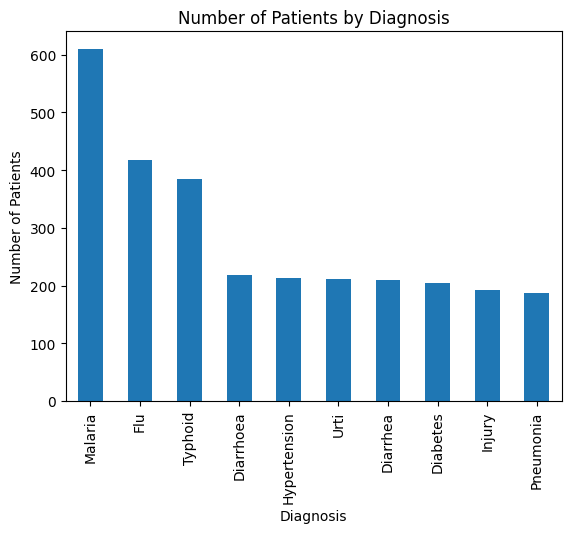

In [ ]:
#VISUALIZATION
#Number of patients per diagnosis
import matplotlib.pyplot as plt

diagnosis_counts = df["diagnosis"].value_counts()

diagnosis_counts.plot(kind="bar")

plt.title("Number of Patients by Diagnosis")
plt.xlabel("Diagnosis")
plt.ylabel("Number of Patients")
plt.show()

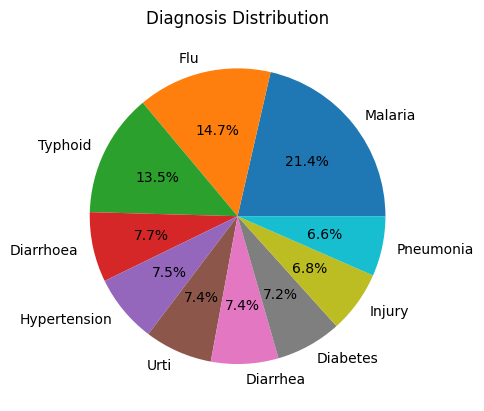

In [ ]:
#the percentage of patients with each diagnosis
import matplotlib.pyplot as plt

df["diagnosis"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Diagnosis Distribution")
plt.ylabel("")
plt.show()